In [121]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

def rmse(y_true, y_pred):
    output = np.sqrt(mean_squared_error(y_true, y_pred))
    return output

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [204]:
import pandas as pd

data = pd.read_csv('mpg.csv', header=None)

# Split the single column using comma
data = data[0].str.split(',', expand=True)

# Set column names
data.columns = [
    'mpg',
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model year',
    'origin',
    'car name'
]

# Remove the original header row
data = data.iloc[1:].reset_index(drop=True)

# Combine X and y temporarily to drop rows cleanly, or drop them from your main DataFrame before splitting:
df_clean = df_clean.dropna(subset=['mpg', 'displacement', 'horsepower', 'weight', 'acceleration'])

data.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18,8,307,130,3504,12,70,1,chevrolet chevelle malibu
1,15,8,350,165,3693,11.5,70,1,buick skylark 320
2,18,8,318,150,3436,11,70,1,plymouth satellite
3,16,8,304,150,3433,12,70,1,amc rebel sst
4,17,8,302,140,3449,10.5,70,1,ford torino
5,15,8,429,198,4341,10,70,1,ford galaxie 500
6,14,8,454,220,4354,9,70,1,chevrolet impala
7,14,8,440,215,4312,8.5,70,1,plymouth fury iii
8,14,8,455,225,4425,10,70,1,pontiac catalina
9,15,8,390,190,3850,8.5,70,1,amc ambassador dpl


In [ ]:
TARGET = 'mpg'
quan_candidates = [ 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']
df_clean = data.copy()
df_clean[quan_candidates].head(10)

,displacement,horsepower,weight,acceleration,model year
0,307,130,3504,12,70
1,350,165,3693,11.5,70
2,318,150,3436,11,70
3,304,150,3433,12,70
4,302,140,3449,10.5,70
5,429,198,4341,10,70
6,454,220,4354,9,70
7,440,215,4312,8.5,70
8,455,225,4425,10,70
9,390,190,3850,8.5,70


In [ ]:
df_clean = data.drop(columns=['origin','car name']).dropna().reset_index(drop=True)
df_clean.head(10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18,8,307,130,3504,12,70
1,15,8,350,165,3693,11.5,70
2,18,8,318,150,3436,11,70
3,16,8,304,150,3433,12,70
4,17,8,302,140,3449,10.5,70
5,15,8,429,198,4341,10,70
6,14,8,454,220,4354,9,70
7,14,8,440,215,4312,8.5,70
8,14,8,455,225,4425,10,70
9,15,8,390,190,3850,8.5,70


# EDA
1. Univariate Analysis
2. Bi-variate Analysis
3. Multi-variate Analysis
4. Co-relational Analysis

### PLOTS
refer this : https://seaborn.pydata.org/examples/


## 1. Univariate Analysis

In [ ]:
cols = [TARGET] + quan_candidates


In [ ]:
# 1. List the numerical columns that are breaking your plots
numeric_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

# 2. Force pandas to treat them as numbers (convert strings/objects to float)
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 3. (Optional) Check the data types to make sure they are float64 or int64 now
print(df_clean[numeric_cols].dtypes)


mpg             float64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
dtype: object


### Bar Plots


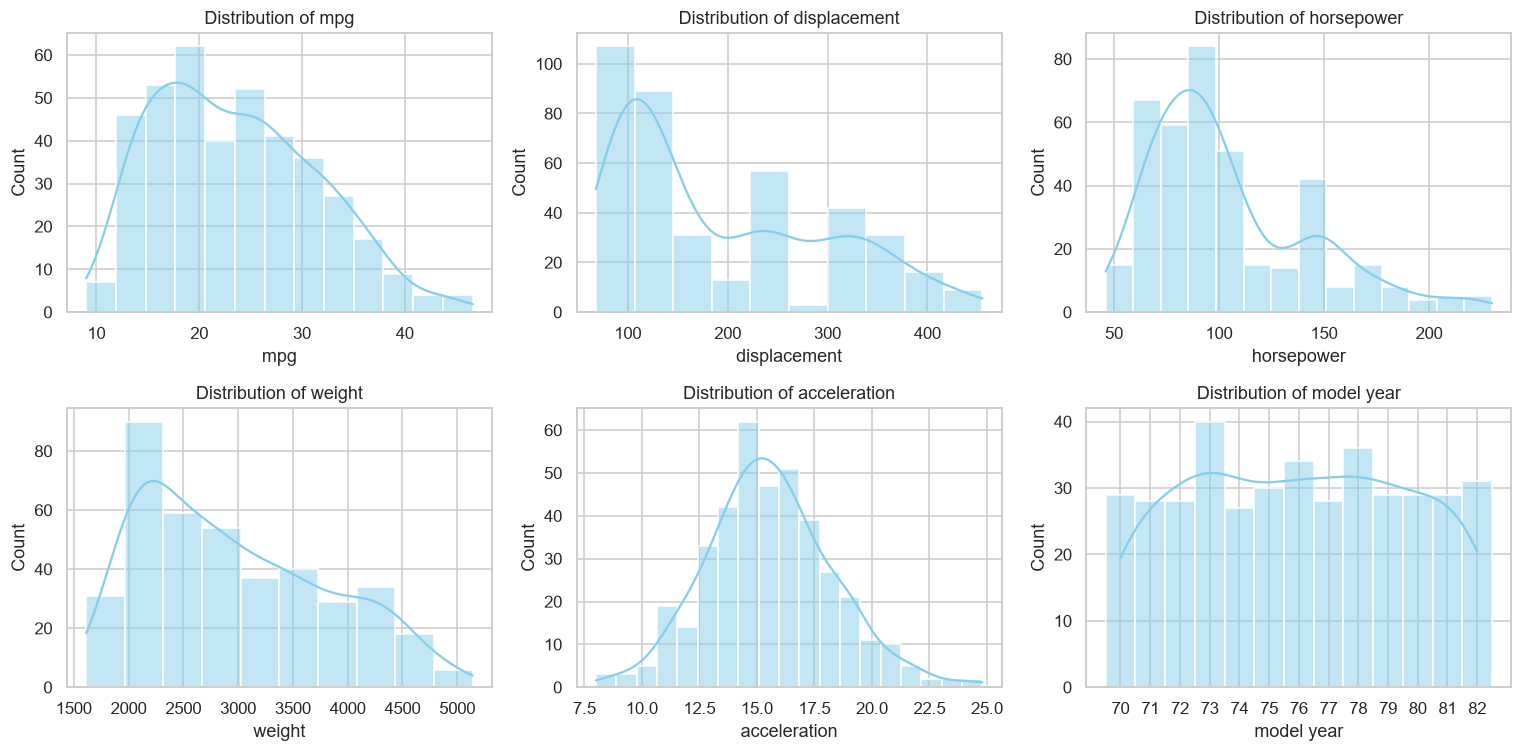

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14,7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.histplot(df_clean[c], ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()

### Skewness 
- having a tail (most of right skewed distribution)
.skew()


### Box Plots

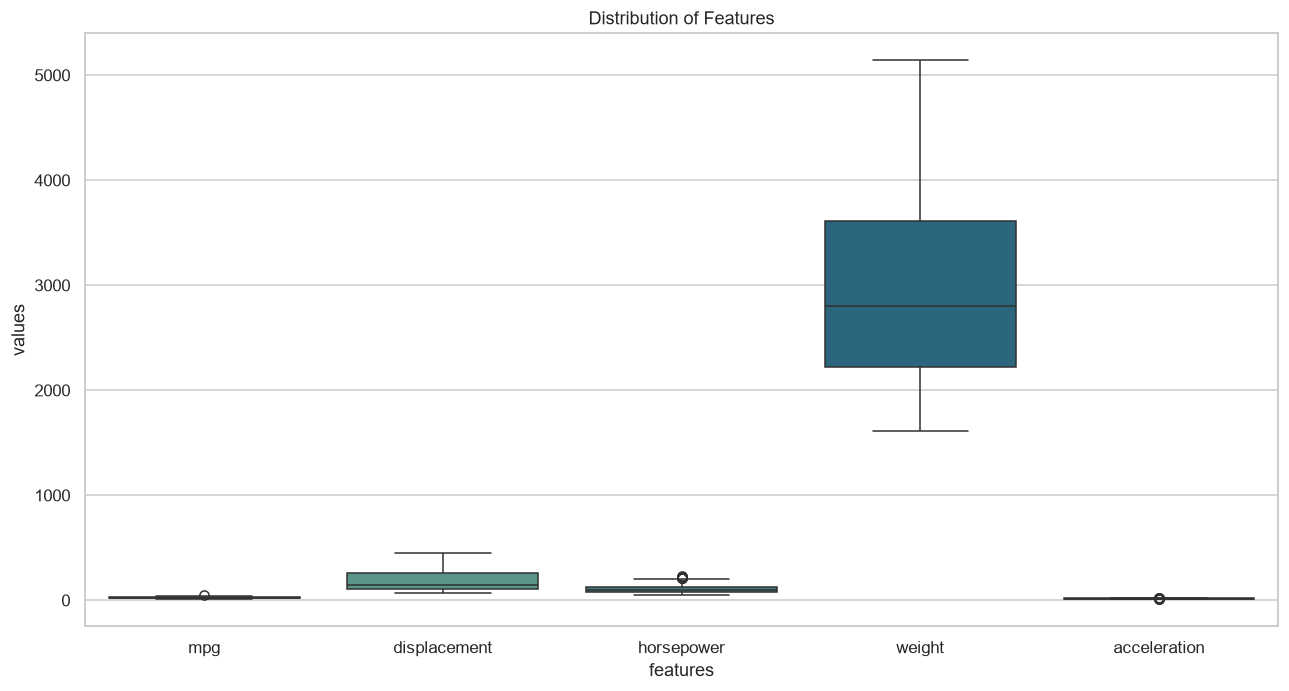

In [ ]:
plt.figure(figsize=(14,7))
sns.boxplot(data=df_clean, palette='crest')
plt.title("Distribution of Features")
plt.xlabel("features")
plt.ylabel("values")
plt.show()

as this box plot shows, the scales are diferent and we need to standardize these plots or create seperate plotes

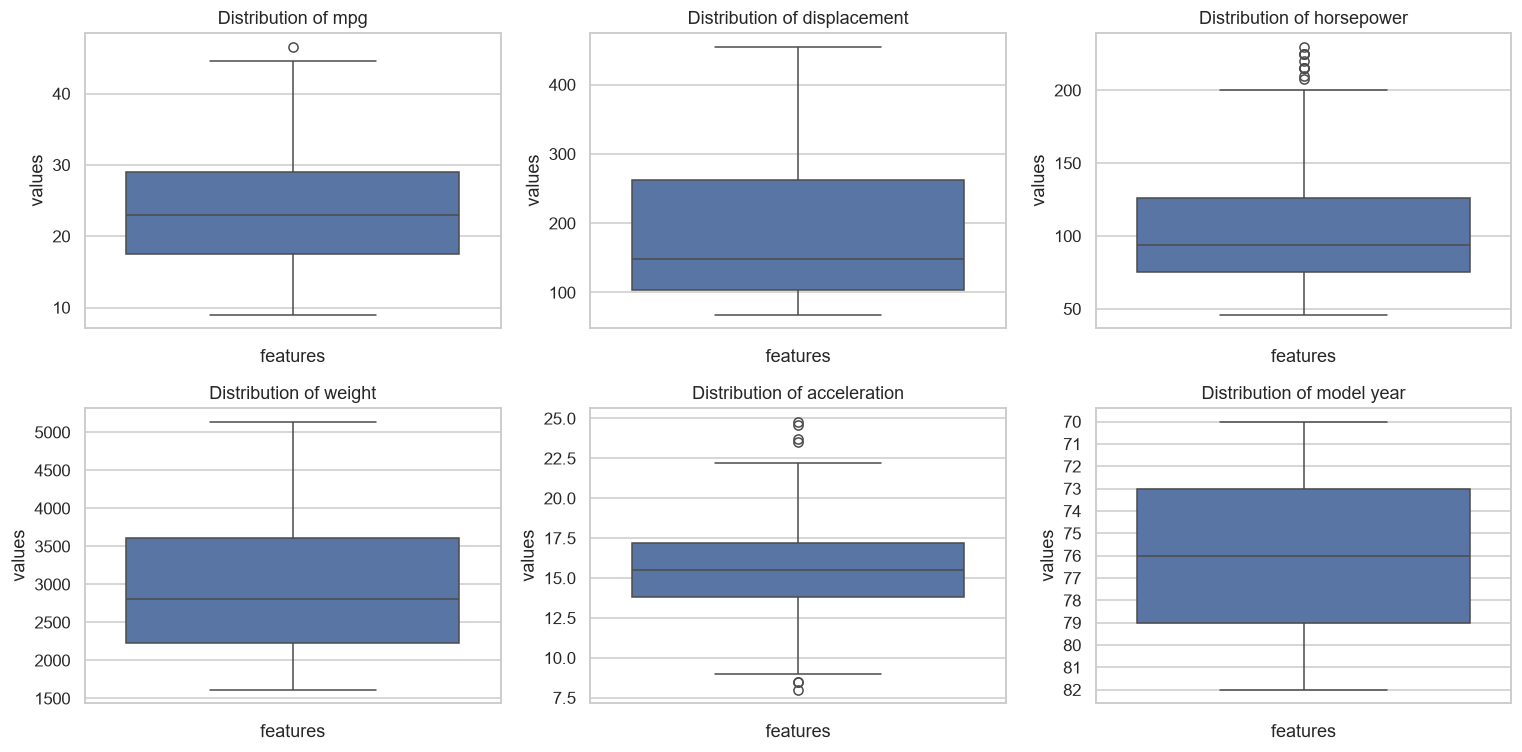

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14,7))
axes = axes.ravel()
for i, c in enumerate(cols):
    sns.boxplot(data=df_clean[c], ax=axes[i])
    axes[i].set_xlabel("features")
    axes[i].set_ylabel("values")
    axes[i].set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()

we can see outliers in horsepower and acceleration. it changes the pattern towards outlier side

## 2. Bi-Variate Analysis



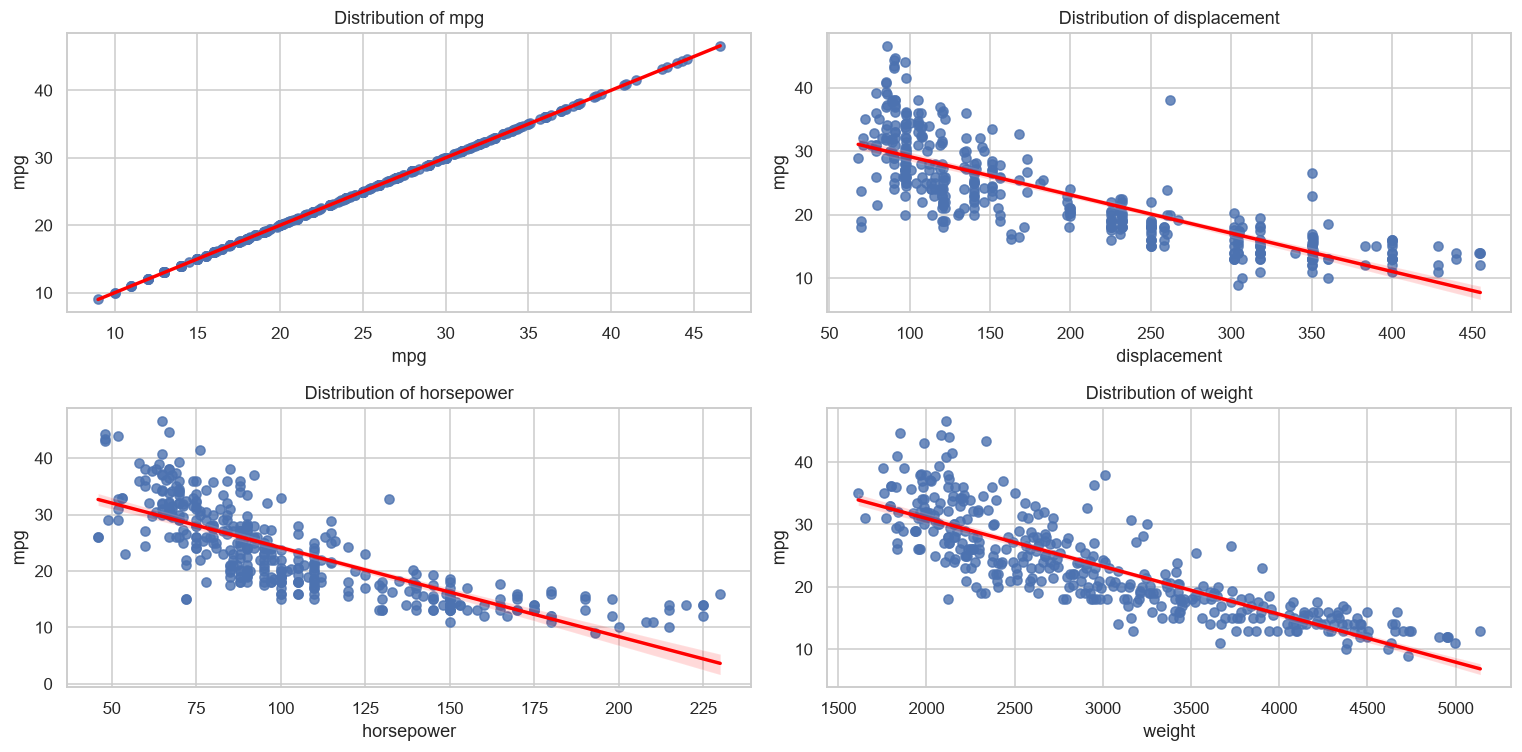

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14,7))
axes = axes.ravel()
for i, c in enumerate(cols[:4]):
    sns.regplot(data=df_clean, x=c, y=TARGET, ax=axes[i], line_kws={'color':'red'})
    axes[i].set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()

## 3. Correlational analysis
if correlation is higher than 0.7, we consider it is strng positive or negetive relationship

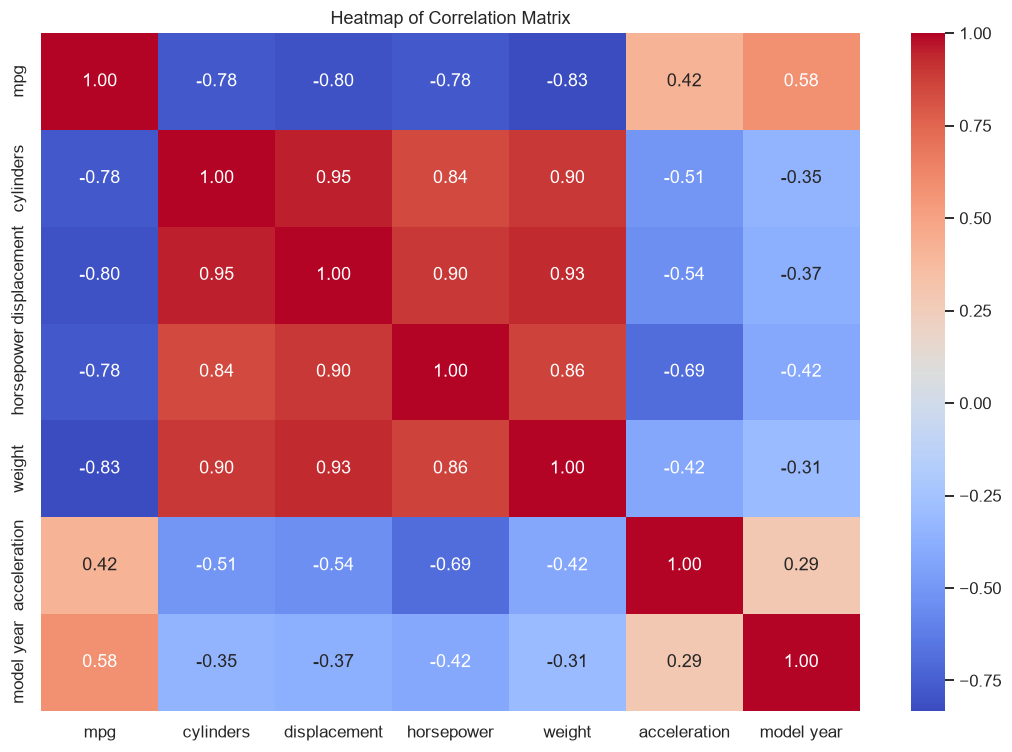

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap of Correlation Matrix")
plt.show()

In [ ]:
df_clean.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


## Multicoreneality
having X variables whic are correlated with each other

__example__

Look at displacement and horsepower in the heat map

- ### linear regression conditions
1. normally distributed features
2. X variables (predictors) should be independant (no correlation) ----> No multicolinearity

- ### Other Models 
if we need to train with multicolinearity data
we can train
1. Ridge Regression
2. LASSO
3. Elastic Nets


# LINEAR REGRESSION 
### MODEL TRAINING
- we cannot train a model by pd series. we need to convert it to the numpy array usding __.values__

In [213]:

Y = df_clean[TARGET].values
X = df_clean[quan_candidates].values
type(Y)
type(X)





numpy.ndarray

### SPLIT DATA

In [214]:
## Train : Test = 70 : 30
# but for huge dataset
## Train : Test = 99 : 1 ---> 99.9 : 0.1

train_size = 0.7
test_size = 0.3

x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=train_size, test_size=test_size, random_state=42)

In [215]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((274, 5), (118, 5), (274,), (118,))

### TRAIN Model

In [216]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-0. ,-0.01,-0.01, 0.06, 0.73]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-12.65
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[13964.6 , 653.56, 274.19, 52.76, 28.86]"


## β values

In [218]:
model.coef_.tolist()

[-0.0010883681139200402,
 -0.009261896919595367,
 -0.0063886700507605615,
 0.06496391205675822,
 0.7294560458614201]

## β Note - Intercept

In [222]:
model.intercept_.tolist()

-12.64540279066349

In [224]:
coefficients = pd.DataFrame(model.coef_, quan_candidates, columns=['Coefficient'])
coefficients

,Coefficient
displacement,-0.001088
horsepower,-0.009262
weight,-0.006389
acceleration,0.064964
model year,0.729456


In [225]:
Y_pred = model.predict(x_test)
Y_pred

array([26.31642996, 26.21895873, 33.16321554, 27.24051243, 29.41014589,
       29.29086692,  7.59504563, 29.4345043 , 21.12584116, 29.41619588,
       12.18811   , 23.91132379, 16.27846284, 28.43320659, 22.08399743,
       30.86385601, 21.49321756, 31.70637   , 28.02569018, 29.77253298,
       20.22898171, 34.57304765, 34.06959898, 15.2720119 , 29.09379776,
       26.20126073, 21.17399151, 16.9648988 , 28.97960515, 24.16723572,
       12.8836965 , 23.77584509, 21.47659658, 29.97924639, 11.04080061,
       34.757423  , 11.11776276, 26.55043884, 11.85655317,  7.45918255,
       13.0659818 , 28.08137337, 34.7147151 , 26.75438054, 11.43599908,
        8.59894909, 17.95453832, 31.59061475, 25.71325994, 30.59460444,
       11.68536645, 25.32611697, 24.70302585, 33.36679128, 28.72324903,
       18.00043776, 21.05894612, 23.30794762, 23.38722702, 24.81864856,
        7.11005187, 23.14150232, 27.31684433, 23.33123871, 28.12040797,
       28.83183494, 26.90801203, 29.85215561, 22.45945033,  9.03

In [226]:
# Y_test, Y_pred
eval = rmse(y_test, Y_pred)
eval

np.float64(3.198117183775828)

In [229]:
# Mean Squared Error
mse = mean_squared_error(y_test, Y_pred)
mse

10.227953521162235

In [228]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, Y_pred)
mae

2.5503387977667855

- __this means we can predict the actual galloons per miles within 2 miles of diviation__